In [1]:
import numpy as np
import pandas as pd


np.random.seed(7911)

portfolio = pd.read_csv("../data/processed/portfolio_with_qx.csv")

portfolio.head()

,policy_id,issue_age,gender,policy_duration,attained_age,qx,expected_deaths
0,1,44,Male,28,72,0.030438,0.030438
1,2,27,Male,30,57,0.010687,0.010687
2,3,63,Female,25,88,0.117435,0.117435
3,4,42,Female,23,65,0.011265,0.011265
4,5,47,Female,10,57,0.006227,0.006227


In [ ]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.experience import (
    simulate_deaths,
    summarize_experience,
    assign_mortality_multiplier,
    summarize_by_age_band,
    calculate_overall_ae
)

from src.visualtization import(
    plot_ae_by_age,
    plot_ae_by_age_band,
    plot_expected_vs_actual
)

In [4]:
print(portfolio)

      policy_id  issue_age  gender  policy_duration  attained_age        qx  \
0             1         44    Male               28            72  0.030438   
1             2         27    Male               30            57  0.010687   
2             3         63  Female               25            88  0.117435   
3             4         42  Female               23            65  0.011265   
4             5         47  Female               10            57  0.006227   
...         ...        ...     ...              ...           ...       ...   
9995       9996         56    Male                3            59  0.012497   
9996       9997         44    Male               30            74  0.036975   
9997       9998         41  Female               15            56  0.005714   
9998       9999         45  Female                7            52  0.004136   
9999      10000         34    Male                5            39  0.003207   

      expected_deaths  
0            0.030438  
1  

## Simulated Mortality Deviations

Because this is a synthetic portfolio, actual mortality was intentionally
simulated to differ from expected mortality.

Assumptions:

- Ages under 50 experience 10% lower mortality than expected.
- Ages 75 and older experience 15% higher mortality than expected.
- Policies in their first five durations experience an additional 15%
  mortality reduction due to underwriting selection.
- A small amount of random variation is added to represent policy-level
  heterogeneity.

In [5]:
portfolio = assign_mortality_multiplier(portfolio)

print(portfolio.columns)

Index(['policy_id', 'issue_age', 'gender', 'policy_duration', 'attained_age',
       'qx', 'expected_deaths', 'mortality_multiplier'],
      dtype='str')


In [6]:


portfolio = simulate_deaths(portfolio)

experience = summarize_experience(portfolio)

display(experience)

,attained_age,exposure,expected_deaths,actual_deaths,expected_rate,actual_rate,AE
0,21,7,0.006704,0,0.000958,0.000000,0.000000
1,22,11,0.012542,0,0.001140,0.000000,0.000000
2,23,15,0.015645,0,0.001043,0.000000,0.000000
3,24,24,0.028824,0,0.001201,0.000000,0.000000
4,25,31,0.037268,0,0.001202,0.000000,0.000000
...,...,...,...,...,...,...,...
75,96,31,9.095151,10,0.293392,0.322581,1.099487
76,97,28,8.516536,6,0.304162,0.214286,0.704512
77,98,10,3.230445,4,0.323045,0.400000,1.238220
78,99,16,5.658528,4,0.353658,0.250000,0.706898


In [7]:
band_experience = summarize_by_age_band(portfolio)

display(band_experience)

,exposure,expected_deaths,actual_deaths,AE
attained_age,,,,
20–29,271,0.369617,0,0.000000
30–39,914,1.895670,1,0.527518
40–49,1599,5.452396,4,0.733622
50–59,1936,13.764244,9,0.653868
60–69,2008,30.376342,14,0.460885
70–79,1770,58.910418,52,0.882696
80–89,1077,97.741336,95,0.971953
90–100,425,98.730834,89,0.901441


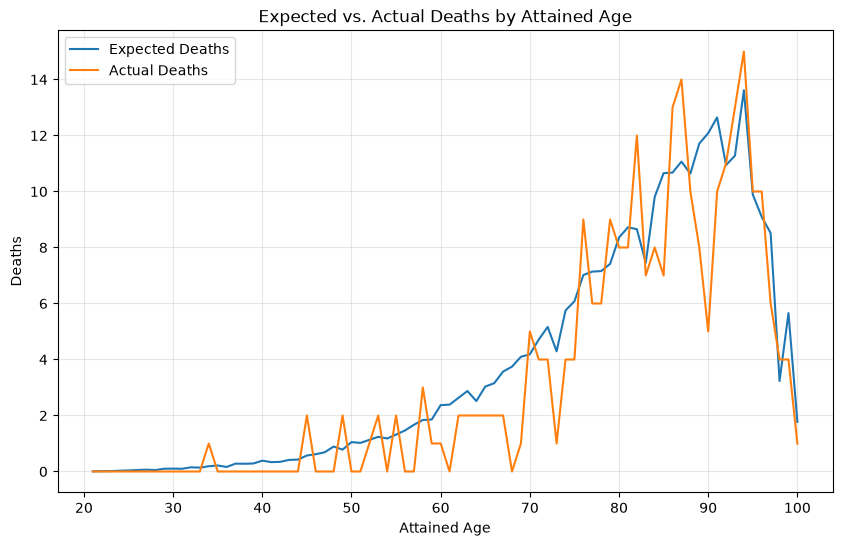

In [ ]:
plot_expected_vs_actual(experience)

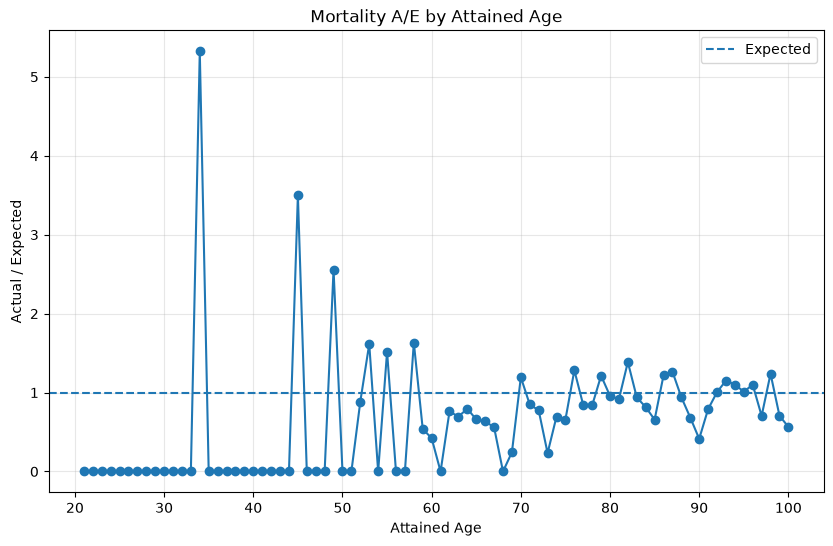

In [ ]:
plot_ae_by_age(experience)

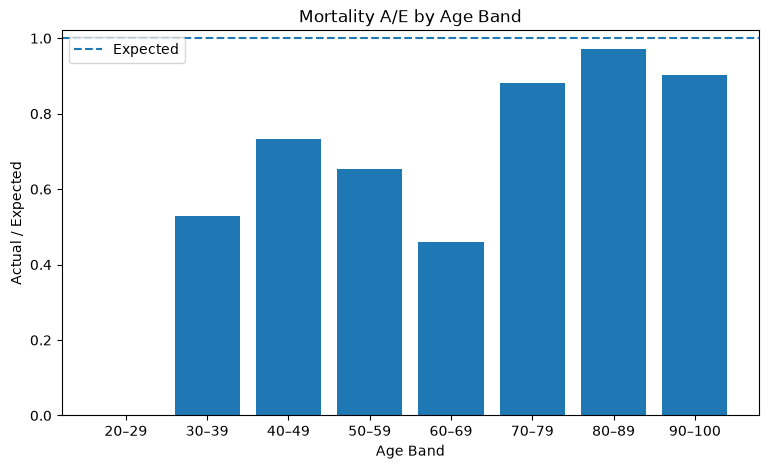

In [ ]:
plot_ae_by_age_band(band_experience)

In [ ]:
calculate_overall_ae(experience)

Overall A/E: 85.93%
